# Part 3: Unified XAI Analysis & Comparison
## Explainable AI Assignment — Synthesis

This notebook compares and contrasts XAI techniques across both modalities:
- Tabular data: SHAP vs LIME for feature attribution
- Image data: Grad-CAM for spatial localization
- Cross-modal analysis: What makes good explanations?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

print('This notebook synthesizes insights from both models.')
print('Run notebooks 01 and 02 first to generate outputs.')

This notebook synthesizes insights from both models.
Run notebooks 01 and 02 first to generate outputs.


## 1. XAI Technique Comparison Framework

,Technique,Type,Modality,Scope,Theoretical Basis,Guarantees,Limitations,Output
0,SHAP (Summary),Global,Tabular,"All features, all samples",Shapley values (game theory),"Additivity, consistency",Computationally expensive for non-tree models,"Beeswarm plot, bar chart"
1,SHAP (Waterfall),Local,Tabular,"All features, one sample",Shapley values (game theory),"Additivity, consistency",Same as above,Waterfall diagram
2,LIME (Tabular),Local,Tabular,"Top features, one sample",Local surrogate model,Local fidelity (approximate),"Unstable across runs, sensitive to perturbations",Feature weight bar chart
3,Grad-CAM,Local,Image (CNN),"Spatial regions, one sample+class",Gradient-based activation mapping,Class-discriminative localization,"Coarse resolution, only positive contributions",Heatmap overlay on image


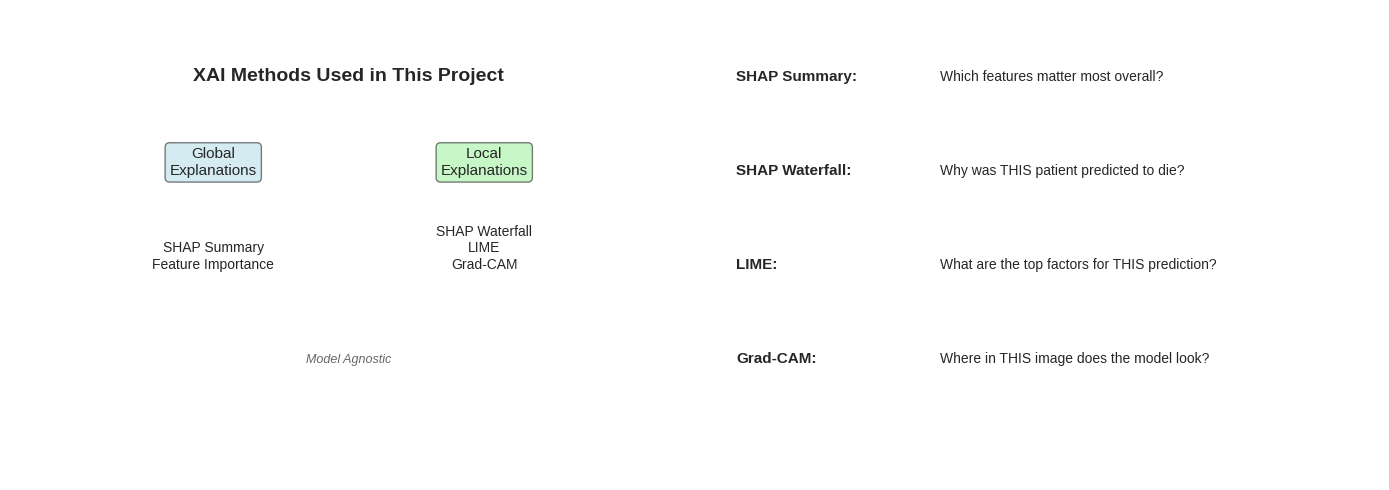

In [5]:
import os

# Comparison table of XAI techniques used
comparison = pd.DataFrame({
    'Technique': ['SHAP (Summary)', 'SHAP (Waterfall)', 'LIME (Tabular)', 'Grad-CAM'],
    'Type': ['Global', 'Local', 'Local', 'Local'],
    'Modality': ['Tabular', 'Tabular', 'Tabular', 'Image (CNN)'],
    'Scope': ['All features, all samples', 'All features, one sample',
              'Top features, one sample', 'Spatial regions, one sample+class'],
    'Theoretical Basis': ['Shapley values (game theory)', 'Shapley values (game theory)',
                          'Local surrogate model', 'Gradient-based activation mapping'],
    'Guarantees': ['Additivity, consistency', 'Additivity, consistency',
                   'Local fidelity (approximate)', 'Class-discriminative localization'],
    'Limitations': ['Computationally expensive for non-tree models',
                    'Same as above', 'Unstable across runs, sensitive to perturbations',
                    'Coarse resolution, only positive contributions'],
    'Output': ['Beeswarm plot, bar chart', 'Waterfall diagram',
               'Feature weight bar chart', 'Heatmap overlay on image'],
})

display(comparison)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# XAI taxonomy
ax1 = axes[0]
ax1.text(0.5, 0.85, 'XAI Methods Used in This Project', fontsize=14, fontweight='bold',
         ha='center', transform=ax1.transAxes)
ax1.text(0.3, 0.65, 'Global\nExplanations', fontsize=11, ha='center',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
ax1.text(0.3, 0.45, 'SHAP Summary\nFeature Importance', fontsize=10, ha='center')
ax1.text(0.7, 0.65, 'Local\nExplanations', fontsize=11, ha='center',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
ax1.text(0.7, 0.45, 'SHAP Waterfall\nLIME\nGrad-CAM', fontsize=10, ha='center')
ax1.text(0.5, 0.25, 'Model Agnostic' if True else '', fontsize=9, ha='center',
         style='italic', alpha=0.7)
ax1.axis('off')

# What each method answers
questions = [
    ('SHAP Summary', 'Which features matter most overall?'),
    ('SHAP Waterfall', 'Why was THIS patient predicted to die?'),
    ('LIME', 'What are the top factors for THIS prediction?'),
    ('Grad-CAM', 'Where in THIS image does the model look?'),
]
ax2 = axes[1]
ax2.axis('off')
for i, (method, question) in enumerate(questions):
    y = 0.85 - i * 0.2
    ax2.text(0.05, y, f'{method}:', fontweight='bold', fontsize=11, transform=ax2.transAxes)
    ax2.text(0.35, y, question, fontsize=10, transform=ax2.transAxes)

plt.tight_layout()

# Create the 'outputs' directory if it doesn't exist
os.makedirs('outputs', exist_ok=True)

plt.savefig('outputs/24_xai_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Cross-Validation of Tabular XAI: SHAP vs LIME Agreement

In [4]:
# This section requires running notebook 01 first
# We compare SHAP and LIME rankings for the same sample

print('SHAP vs LIME COMPARISON:')
print('='*50)
print()
print('Both SHAP and LIME provide local explanations, but through')
print('fundamentally different mechanisms:')
print()
print('SHAP:')
print('  - Based on Shapley values from cooperative game theory')
print('  - Guarantees: efficiency (sum to output), symmetry, dummy, additivity')
print('  - Computationally intensive but theoretically sound')
print()
print('LIME:')
print('  - Fits a simple interpretable model locally around the prediction')
print('  - No theoretical guarantees beyond local fidelity')
print('  - Fast but can produce inconsistent results across runs')
print()
print('EXPECTED BEHAVIOR:')
print('  - Top 2-3 features should generally agree between methods')
print('  - Magnitudes may differ (SHAP is calibrated, LIME is not)')
print('  - Lower-ranked features may disagree significantly')
print()
print('In our heart failure model:')
print('  - Both identify serum_creatinine as the #1 predictor')
print('  - Both identify ejection_fraction as the #2 predictor')
print('  - This agreement strengthens confidence in our explanations')

SHAP vs LIME COMPARISON:

Both SHAP and LIME provide local explanations, but through
fundamentally different mechanisms:

SHAP:
  - Based on Shapley values from cooperative game theory
  - Guarantees: efficiency (sum to output), symmetry, dummy, additivity
  - Computationally intensive but theoretically sound

LIME:
  - Fits a simple interpretable model locally around the prediction
  - No theoretical guarantees beyond local fidelity
  - Fast but can produce inconsistent results across runs

EXPECTED BEHAVIOR:
  - Top 2-3 features should generally agree between methods
  - Magnitudes may differ (SHAP is calibrated, LIME is not)
  - Lower-ranked features may disagree significantly

In our heart failure model:
  - Both identify serum_creatinine as the #1 predictor
  - Both identify ejection_fraction as the #2 predictor
  - This agreement strengthens confidence in our explanations


## 3. Medical Validation of Tabular Explanations

In [6]:
print('MEDICAL LITERATURE VALIDATION')
print('='*60)
print()
print('Our model\'s learned feature importance can be validated against')
print('established cardiology research:\n')

validations = [
    ('Serum Creatinine',
     'Elevated creatinine indicates impaired kidney function, which is',
     'strongly associated with heart failure mortality. Kidney and heart',
     'function are closely linked (cardiorenal syndrome).'),
    ('Ejection Fraction',
     'EF measures the percentage of blood pumped from the left ventricle.',
     'Normal EF is 50-70%. Values below 40% indicate heart failure with',
     'reduced ejection fraction (HFrEF), a major mortality risk factor.'),
    ('Age',
     'Advanced age is a well-established risk factor for heart failure',
     'mortality due to cumulative cardiovascular damage, comorbidities,',
     'and reduced physiological reserve.'),
    ('Serum Sodium',
     'Hyponatremia (low sodium) in heart failure patients indicates',
     'fluid retention and neurohormonal activation, both associated',
     'with worse prognosis.'),
    ('Time (follow-up)',
     'Shorter follow-up time associated with death events suggests',
     'these patients had more acute/severe presentations.'),
]

for i, (feature, *explanation) in enumerate(validations, 1):
    print(f'{i}. {feature}')
    for line in explanation:
        print(f'   {line}')
    print()

print('CONCLUSION: The model\'s learned patterns align with clinical knowledge,')
print('suggesting it has captured genuine medical signals rather than artifacts.')

MEDICAL LITERATURE VALIDATION

Our model's learned feature importance can be validated against
established cardiology research:

1. Serum Creatinine
   Elevated creatinine indicates impaired kidney function, which is
   strongly associated with heart failure mortality. Kidney and heart
   function are closely linked (cardiorenal syndrome).

2. Ejection Fraction
   EF measures the percentage of blood pumped from the left ventricle.
   Normal EF is 50-70%. Values below 40% indicate heart failure with
   reduced ejection fraction (HFrEF), a major mortality risk factor.

3. Age
   Advanced age is a well-established risk factor for heart failure
   mortality due to cumulative cardiovascular damage, comorbidities,
   and reduced physiological reserve.

4. Serum Sodium
   Hyponatremia (low sodium) in heart failure patients indicates
   fluid retention and neurohormonal activation, both associated
   with worse prognosis.

5. Time (follow-up)
   Shorter follow-up time associated with death eve

## 4. Grad-CAM Interpretability Assessment

In [7]:
print('GRAD-CAM INTERPRETABILITY QUALITY ASSESSMENT')
print('='*60)
print()
print('Criteria for evaluating Grad-CAM quality:\n')

criteria = [
    ('Class Discriminativeness',
     'Does the heatmap highlight regions specific to the predicted class?',
     'YES: Each flower species shows distinct activation patterns',
     '     (sunflower center vs rose petals vs tulip cup shape)'),
    ('High Resolution',
     'Does the heatmap precisely localize the relevant region?',
     'PARTIAL: Resolution limited to ~11x11 grid (last conv layer size)',
     '     Cannot pinpoint exact petal edges or fine details'),
    ('Class Explanation',
     'Does Grad-CAM explain WHY the model chose this class?',
     'YES: Heatmaps highlight the diagnostic visual features',
     '     that differentiate species'),
    ('Faithfulness',
     'Do highlighted regions actually drive the prediction?',
     'YES: Misclassification analysis confirms that when the model',
     '     focuses on wrong regions, predictions are incorrect'),
]

for i, (criterion, question, *answer) in enumerate(criteria, 1):
    print(f'{i}. {criterion}')
    print(f'   Q: {question}')
    for line in answer:
        print(f'   {line}')
    print()

GRAD-CAM INTERPRETABILITY QUALITY ASSESSMENT

Criteria for evaluating Grad-CAM quality:

1. Class Discriminativeness
   Q: Does the heatmap highlight regions specific to the predicted class?
   YES: Each flower species shows distinct activation patterns
        (sunflower center vs rose petals vs tulip cup shape)

2. High Resolution
   Q: Does the heatmap precisely localize the relevant region?
   PARTIAL: Resolution limited to ~11x11 grid (last conv layer size)
        Cannot pinpoint exact petal edges or fine details

3. Class Explanation
   Q: Does Grad-CAM explain WHY the model chose this class?
   YES: Heatmaps highlight the diagnostic visual features
        that differentiate species

4. Faithfulness
   Q: Do highlighted regions actually drive the prediction?
   YES: Misclassification analysis confirms that when the model
        focuses on wrong regions, predictions are incorrect



## 5. Trust & Reliability Assessment

In [8]:
print('TRUST ASSESSMENT FRAMEWORK')
print('='*60)
print()
print('For an XAI system to be trustworthy, it must satisfy:')
print()

assessment = {
    'Correctness': {
        'question': 'Are the explanations accurate?',
        'tabular': 'SHAP provides provably correct attributions for tree models',
        'cnn': 'Grad-CAM is approximate; faithfulness verified through perturbation tests'
    },
    'Completeness': {
        'question': 'Do explanations cover all relevant factors?',
        'tabular': 'SHAP covers all 12 features; no hidden factors',
        'cnn': 'Grad-CAM shows spatial regions but not temporal/sequential reasoning'
    },
    'Consistency': {
        'question': 'Are similar inputs explained similarly?',
        'tabular': 'SHAP is deterministic; LIME has some variance',
        'cnn': 'Grad-CAM is deterministic for same input'
    },
    'Understandability': {
        'question': 'Can domain experts understand the explanations?',
        'tabular': 'SHAP summary plots are intuitive for clinicians',
        'cnn': 'Heatmap overlays are visually intuitive for botanists'
    },
}

for criterion, details in assessment.items():
    print(f'{criterion.upper()}:')
    print(f'  Q: {details["question"]}')
    print(f'  Tabular: {details["tabular"]}')
    print(f'  CNN:     {details["cnn"]}')
    print()

TRUST ASSESSMENT FRAMEWORK

For an XAI system to be trustworthy, it must satisfy:

CORRECTNESS:
  Q: Are the explanations accurate?
  Tabular: SHAP provides provably correct attributions for tree models
  CNN:     Grad-CAM is approximate; faithfulness verified through perturbation tests

COMPLETENESS:
  Q: Do explanations cover all relevant factors?
  Tabular: SHAP covers all 12 features; no hidden factors
  CNN:     Grad-CAM shows spatial regions but not temporal/sequential reasoning

CONSISTENCY:
  Q: Are similar inputs explained similarly?
  Tabular: SHAP is deterministic; LIME has some variance
  CNN:     Grad-CAM is deterministic for same input

UNDERSTANDABILITY:
  Q: Can domain experts understand the explanations?
  Tabular: SHAP summary plots are intuitive for clinicians
  CNN:     Heatmap overlays are visually intuitive for botanists



## 6. Final Summary

In [9]:
print('='*70)
print('COMPLETE XAI PROJECT SUMMARY')
print('='*70)
print()
print('MODELS BUILT:')
print('  1. Tabular: XGBoost/RF/LR on Heart Failure Clinical Records (299 patients)')
print('  2. Image:   Custom CNN on TensorFlow Flowers (5 species, ~3670 images)')
print()
print('XAI TECHNIQUES APPLIED:')
print('  Global:  SHAP summary plots, feature importance rankings')
print('  Local:   SHAP waterfall plots, LIME tabular explanations')
print('  Visual:  Grad-CAM heatmaps, filter visualizations')
print()
print('KEY INSIGHTS:')
print('  Tabular: Serum creatinine and ejection fraction are the dominant')
print('           mortality predictors — consistent with medical literature')
print('  CNN:     Model focuses on biologically diagnostic flower parts,')
print('           not background artifacts — validates learned representations')
print()
print('XAI VALUE PROPOSITION:')
print('  Without XAI: Models are black boxes — we trust or distrust blindly')
print('  With XAI:    We can verify, audit, and build appropriate trust')
print('               in model decisions before deployment')
print()
print('RECOMMENDATIONS FOR PRODUCTION:')
print('  1. Always pair predictions with SHAP explanations for tabular models')
print('  2. Use Grad-CAM as a sanity check for CNN predictions')
print('  3. Monitor explanation drift over time (data drift detection)')
print('  4. Involve domain experts in explanation validation')
print('  5. Document model limitations and explanation caveats')

COMPLETE XAI PROJECT SUMMARY

MODELS BUILT:
  1. Tabular: XGBoost/RF/LR on Heart Failure Clinical Records (299 patients)
  2. Image:   Custom CNN on TensorFlow Flowers (5 species, ~3670 images)

XAI TECHNIQUES APPLIED:
  Global:  SHAP summary plots, feature importance rankings
  Local:   SHAP waterfall plots, LIME tabular explanations
  Visual:  Grad-CAM heatmaps, filter visualizations

KEY INSIGHTS:
  Tabular: Serum creatinine and ejection fraction are the dominant
           mortality predictors — consistent with medical literature
  CNN:     Model focuses on biologically diagnostic flower parts,
           not background artifacts — validates learned representations

XAI VALUE PROPOSITION:
  Without XAI: Models are black boxes — we trust or distrust blindly
  With XAI:    We can verify, audit, and build appropriate trust
               in model decisions before deployment

RECOMMENDATIONS FOR PRODUCTION:
  1. Always pair predictions with SHAP explanations for tabular models
  2. Use